[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/halla-ai/deepnlp-2026/blob/main/notebooks/week-07.ipynb)

# 7주차 실습: 장문맥 처리와 효율적 추론

**목표.** 긴 한국어 문서(위키백과 「제주특별자치도」 고정판)로 세 가지를 해 본다.

1. **문맥이 길어지면 무엇이 비싸지는가**: 모델 설정에서 KV 캐시 크기를 계산하고, 프리필(입력 읽기)과 디코딩(한 토큰씩 쓰기) 시간을 직접 잰다
2. **위치 인코딩이 길이를 정하는 방식**: RoPE의 차원 쌍별 회전 주기를 계산해 학습 길이 밖이 왜 문제인지 본다
3. **위치별 정보 회수율**: 문서 곳곳에 가상의 문장을 숨기고 모델이 찾아내는지 잰다. **문서 길이를 바꿔 가며** 길이-정확도 곡선을 그린다

GPU는 필요 없다. 노트북이 실행 시점에 문서와 모델을 내려받는다. 문서는 위키백과 본문(CC BY-SA 4.0)이고, 숨기는 문장(안내센터 출입 번호)은 실험용으로 지어낸 것이다.


학번: 202221015

- 실험 변수: TODO의 `LENGTHS`를 `[250, 500, 1000]`에서 `[250, 500, 1000, 2000, 4000]`으로 확장. 짧은 길이의 기준 조건을 유지하고 길어진 조건을 같은 설정으로 비교.
- 실행 설정: CPU 4 threads, float32, 탐욕 디코딩, 원본 seed=0 및 가상 번호 생성 seed=7 유지. 모델 리비전 고정, 실제 버전과 입력 길이는 아래 출력에 기록.
- TODO 외 보완: 조건부 설치, 출처와 데이터 해시, 4,000토큰 프리필 추가 계측, 문항별 생성 결과 및 측정값 보존. 원본의 2,000토큰 디코딩 비교는 유지.
- 문서: 한국어 위키백과 기여자들의 [제주특별자치도, 판 42464087](https://ko.wikipedia.org/w/index.php?title=제주특별자치도&oldid=42464087), 2026-09-11 판, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). 표/태그/각주를 제거한 본문 문단으로 실험하며, 틀 렌더링 변화 가능성을 해시와 크기로 기록. 안내센터 번호는 실험용으로 생성한 가상 값.
- 생성형 AI의 코드 작성과 결과 정리 보조를 사용. 실행하지 않은 값을 측정값으로 사용하지 않으며, 학습자 개인의 이해도를 검증한 기록으로 주장하지 않음.

## 0. 준비

아래 셀을 실행해 필요한 라이브러리를 설치한다. GPU는 필요 없다.

In [1]:
# 이미 준비된 실행 환경은 유지하고, 없는 라이브러리만 설치.
import importlib.util
import importlib.metadata
import subprocess
import sys
import os
from pathlib import Path

requirements = {"transformers": "transformers==4.57.6", "torch": "torch==2.8.0", "matplotlib": "matplotlib>=3.10,<4"}
missing = [spec for module, spec in requirements.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
import torch
torch.set_num_threads(4)
print("Python:", sys.version.split()[0])
for package in requirements:
    print(package, importlib.metadata.version(package))
print("계산 장치: CPU / threads:", torch.get_num_threads())

Python: 3.10.0
transformers 4.57.6
torch 2.8.0+cpu
matplotlib 3.10.9
계산 장치: CPU / threads: 4


## 1. 먼저 그냥 실행해 보기

아래 셀들을 위에서부터 차례로 실행하세요. 아무것도 고치지 않아도 끝까지 돌아갑니다.

### 1-1. 문서 불러오기 - 위키백과 고정판

위키백과 「제주특별자치도」 문서의 **2026-09-11 판(판 번호 42464087)** 을 내려받는다. 판 번호를 고정했으므로 누가 언제 실행해도 본문은 사실상 같은 글이다(위키백과의 틀이 바뀌면 글자 수가 조금 달라질 수 있다). 표, 각주, 목차는 버리고 본문 문단만 쓴다.

In [2]:
import re, html, json, urllib.request, urllib.parse

OLDID = 42464087  # 위키백과 「제주특별자치도」 2026-09-11 판 (고정)
url = "https://ko.wikipedia.org/w/api.php?" + urllib.parse.urlencode(
    {"action": "parse", "oldid": OLDID, "prop": "text", "format": "json", "formatversion": 2})
req = urllib.request.Request(url, headers={"User-Agent": "deepnlp-course-student/1.0 (https://github.com/halla-ai/deepnlp-2026)"})
with urllib.request.urlopen(req, timeout=60) as response:
    parsed = json.load(response)["parse"]
assert parsed["revid"] == OLDID, "요청한 고정 판과 응답의 판 번호가 다름"
raw = parsed["text"]

def clean(p):
    p = re.sub(r"<sup.*?</sup>", "", p, flags=re.S)  # 각주 번호 제거
    p = re.sub(r"<[^>]+>", "", p)                     # 태그 제거
    return re.sub(r"\s+", " ", html.unescape(p)).strip()

paras = [clean(p) for p in re.findall(r"<p>(.*?)</p>", raw, flags=re.S)]
paras = [p for p in paras if len(p) > 40]
# 문장 단위로 자른다. 숨길 문장을 문장 사이에 끼우기 위해서다
sents = [s.strip() for p in paras for s in re.split(r"(?<=[.다])\s+", p) if s.strip()]
n_chars = sum(len(p) for p in paras)
print(f"문단 {len(paras)}개, 문장 {len(sents)}개, {n_chars:,}자")
print("첫 문장:", sents[0][:80], "...")


import hashlib
doc_hash = hashlib.sha256("\n".join(paras).encode("utf-8")).hexdigest()
print("문서 판 번호:", parsed["revid"], "/ 정제 문단 SHA256:", doc_hash)

문단 58개, 문장 160개, 10,556자
첫 문장: 제주특별자치도(濟州特別自治道, 제주어: 제주특벨ᄌᆞ치도, 영어: Jeju Special Self-Governing Province)는 대한민국의 ...
문서 판 번호: 42464087 / 정제 문단 SHA256: 63257fcc7658838f8714f4bf09d50e10c91ba62742d7248664b1541c6728f59e


### 1-2. 모델 불러오기와 설정 읽기

4~6주차와 같은 Qwen3-0.6B-Base를 쓴다. 장문맥과 관련된 설정값(층 수, 헤드 수, 최대 위치, RoPE 기저)을 먼저 읽어 둔다. 아래 계산이 모두 이 값에서 나온다.

In [3]:
import time, torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)

name = "Qwen/Qwen3-0.6B-Base"
MODEL_REVISION = "da87bfb608c14b7cf20ba1ce41287e8de496c0cd"
tok = AutoTokenizer.from_pretrained(name, revision=MODEL_REVISION)
model = AutoModelForCausalLM.from_pretrained(name, revision=MODEL_REVISION, dtype=torch.float32).to("cpu").eval()
cfg = model.config
rope_theta = cfg.rope_parameters["rope_theta"] if getattr(cfg, "rope_parameters", None) else cfg.rope_theta
n_params = sum(p.numel() for p in model.parameters())

print(f"층 수              {cfg.num_hidden_layers}")
print(f"쿼리 헤드 수        {cfg.num_attention_heads}")
print(f"KV 헤드 수          {cfg.num_key_value_heads}  (쿼리 헤드 {cfg.num_attention_heads // cfg.num_key_value_heads}개가 KV 헤드 1개를 함께 쓴다 = GQA)")
print(f"헤드 차원           {cfg.head_dim}")
print(f"최대 위치           {cfg.max_position_embeddings:,}")
print(f"RoPE 기저 b         {rope_theta:,.0f}")
print(f"파라미터 수         {n_params:,}")

doc_tokens = len(tok(" ".join(sents), add_special_tokens=False).input_ids)
print(f"\n문서 전체 {n_chars:,}자 = {doc_tokens:,}토큰 (토큰 하나에 평균 {n_chars / doc_tokens:.2f}자)")


print("모델 revision:", model.config._commit_hash)
print("실제 장치/dtype:", next(model.parameters()).device, next(model.parameters()).dtype)

C:\Users\User\Desktop\School2\tmp\deepnlp_20261007\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


층 수              28
쿼리 헤드 수        16
KV 헤드 수          8  (쿼리 헤드 2개가 KV 헤드 1개를 함께 쓴다 = GQA)
헤드 차원           128
최대 위치           32,768
RoPE 기저 b         1,000,000
파라미터 수         596,049,920

문서 전체 10,556자 = 7,884토큰 (토큰 하나에 평균 1.34자)
모델 revision: da87bfb608c14b7cf20ba1ce41287e8de496c0cd
실제 장치/dtype: cpu torch.float32


### 1-3. KV 캐시 크기 계산 - 문맥 길이에 정비례

디코딩할 때 모델은 앞 토큰들의 Key와 Value를 층마다 저장해 둔다(KV 캐시). 크기는 다음과 같다.

`KV 캐시 = 2 (K와 V) x 층 수 x KV 헤드 수 x 헤드 차원 x 바이트 x 토큰 수`

모델을 돌리지 않고 설정값만으로 계산한다. 바이트는 배포에 흔히 쓰는 bf16(2바이트)으로 잡는다. 이 노트북은 CPU 속도 때문에 fp32(4바이트)로 돌리므로 실제 메모리는 2배다.

In [4]:
BYTES = 2  # bf16
per_token = 2 * cfg.num_hidden_layers * cfg.num_key_value_heads * cfg.head_dim * BYTES
weights = n_params * BYTES
print(f"토큰당 KV 캐시: {per_token:,}바이트 = {per_token / 1024:.0f} KiB")
print(f"가중치 (bf16):  {weights / 2**30:.2f} GiB\n")
print(f"{'문맥 길이':>10} | {'KV 캐시':>10} | 가중치 대비")
for n in [1024, 4096, 8192, 16384, 32768]:
    kv = per_token * n
    print(f"{n:>10,} | {kv / 2**30:>6.2f} GiB | {kv / weights:>5.2f}배")
print(f"\nKV 캐시가 가중치와 같아지는 길이: 약 {weights / per_token:,.0f}토큰")
mha = 2 * cfg.num_hidden_layers * cfg.num_attention_heads * cfg.head_dim * BYTES
print(f"KV 헤드를 쿼리 헤드 수({cfg.num_attention_heads})만큼 두었다면(MHA) 토큰당 {mha / 1024:.0f} KiB, 지금의 {mha / per_token:.0f}배")

토큰당 KV 캐시: 114,688바이트 = 112 KiB
가중치 (bf16):  1.11 GiB

     문맥 길이 |      KV 캐시 | 가중치 대비
     1,024 |   0.11 GiB |  0.10배
     4,096 |   0.44 GiB |  0.39배
     8,192 |   0.88 GiB |  0.79배
    16,384 |   1.75 GiB |  1.58배
    32,768 |   3.50 GiB |  3.15배

KV 캐시가 가중치와 같아지는 길이: 약 10,394토큰
KV 헤드를 쿼리 헤드 수(16)만큼 두었다면(MHA) 토큰당 224 KiB, 지금의 2배


### 1-4. RoPE 주기 - 학습 길이 밖은 왜 문제인가

RoPE는 위치 i의 토큰을 차원 쌍마다 각도 i x θ_k 만큼 돌린다. 차원 쌍 k의 회전 속도는 θ_k = b^(-2(k-1)/d) 이고, 한 바퀴 도는 데 걸리는 토큰 수(주기)는 T_k = 2π x b^(2(k-1)/d) 다. 빠른 쌍은 몇 토큰마다 한 바퀴를 돌고, 느린 쌍은 최대 위치 안에서 한 바퀴도 못 돈다. 느린 쌍은 학습 때 본 각도 범위가 좁으므로, 학습 길이를 넘으면 처음 보는 각도가 나온다.

In [5]:
import math
d = cfg.head_dim
T = [2 * math.pi * rope_theta ** (2 * (k - 1) / d) for k in range(1, d // 2 + 1)]
ML = cfg.max_position_embeddings
print(f"차원 쌍 {d // 2}개")
print(f"가장 빠른 쌍 (k=1):  {T[0]:.2f}토큰마다 한 바퀴")
print(f"가장 느린 쌍 (k={d // 2}): {T[-1]:,.0f}토큰마다 한 바퀴")
print(f"최대 위치 {ML:,} 안에서 한 바퀴도 못 도는 쌍: {sum(t > ML for t in T)}개")
print(f"가장 느린 쌍이 위치 {ML:,}까지 도는 각도: {math.degrees(2 * math.pi * ML / T[-1]):.1f}도")

# 위치 보간: 4배 긴 문맥(m)을 학습 길이(m_l) 안에 넣으려면 위치를 m_l / m 배로 줄인다
m = 4 * ML
print(f"\n위치 보간 예: 길이 {m:,}를 {ML:,} 안에 넣기 -> 위치 100,000은 {100_000 * ML / m:,.0f}로 바뀐다")
# 기저 늘리기: 가장 느린 쌍의 주기가 위치 보간과 같아지도록 b를 lambda배 한다
lam = (m / ML) ** (d / (d - 2))
T2 = [2 * math.pi * (lam * rope_theta) ** (2 * (k - 1) / d) for k in range(1, d // 2 + 1)]
print(f"기저 늘리기 예: lambda = {lam:.4f}, 가장 빠른 쌍 주기 {T[0]:.2f} -> {T2[0]:.2f} (그대로), 가장 느린 쌍 {T[-1]:,.0f} -> {T2[-1]:,.0f} ({T2[-1] / T[-1]:.2f}배)")

차원 쌍 64개
가장 빠른 쌍 (k=1):  6.28토큰마다 한 바퀴
가장 느린 쌍 (k=64): 5,063,256토큰마다 한 바퀴
최대 위치 32,768 안에서 한 바퀴도 못 도는 쌍: 24개
가장 느린 쌍이 위치 32,768까지 도는 각도: 2.3도

위치 보간 예: 길이 131,072를 32,768 안에 넣기 -> 위치 100,000은 25,000로 바뀐다
기저 늘리기 예: lambda = 4.0890, 가장 빠른 쌍 주기 6.28 -> 6.28 (그대로), 가장 느린 쌍 5,063,256 -> 20,253,023 (4.00배)


### 1-5. 프리필과 디코딩 시간 재기

추론은 두 단계다. **프리필**은 입력 전체를 한 번에 읽어 KV 캐시를 만든다. **디코딩**은 그 캐시를 읽으며 한 토큰씩 쓴다. 문서 앞부분을 길이별로 잘라 프리필 시간을 재고, 가장 긴 입력에서 디코딩 토큰당 시간을 잰다.

- 프리필은 `logits_to_keep=1`로 잰다. 다음 토큰을 고르는 데 필요한 마지막 자리의 확률만 계산하는 것으로, `generate`가 실제로 하는 방식과 같다
- 디코딩 토큰당 시간은 1토큰 생성 시간(첫 토큰까지 시간)과 20토큰 생성 시간의 차이를 19로 나눠 구한다

시간은 실행 환경마다 다르다. 절대값보다 **길이에 따라 늘어나는 모양**을 본다.

In [6]:
full_ids = tok(" ".join(sents), return_tensors="pt").input_ids
PREFILL_LENGTHS = [250, 500, 1000, 2000]
prefill_sec = {}
with torch.no_grad():
    model(full_ids[:, :50], logits_to_keep=1)  # 첫 호출의 준비 시간을 측정에서 빼기 위한 예열
    for n in PREFILL_LENGTHS:
        t = time.perf_counter()
        model(full_ids[:, :n], logits_to_keep=1)  # 마지막 자리의 확률만 계산 (generate와 같은 방식)
        prefill_sec[n] = time.perf_counter() - t
        print(f"입력 {n:>5,}토큰 프리필: {prefill_sec[n]:.2f}초")

n = PREFILL_LENGTHS[-1]
NEW = 20
def gen_time(k):
    t = time.perf_counter()
    with torch.no_grad():
        model.generate(full_ids[:, :n], max_new_tokens=k, min_new_tokens=k, do_sample=False, pad_token_id=tok.eos_token_id)
    return time.perf_counter() - t
ttft = gen_time(1)       # 첫 토큰까지 시간: 프리필 + 첫 토큰
total = gen_time(NEW)
decode_per_tok = (total - ttft) / (NEW - 1)
print(f"\n입력 {n:,}토큰 뒤 1토큰 생성(첫 토큰까지 시간): {ttft:.2f}초, {NEW}토큰 생성: {total:.2f}초")
print(f"  이후 토큰당 약 {decode_per_tok:.3f}초 = ({total:.2f} - {ttft:.2f}) / {NEW - 1}")


# 길이 확장과 맞춘 추가 계측. 원본 n=2000의 디코딩 비교는 위에서 그대로 수행.
with torch.no_grad():
    t = time.perf_counter()
    model(full_ids[:, :4000], logits_to_keep=1)
    prefill_sec[4000] = time.perf_counter() - t
print(f"추가 입력 4,000토큰 프리필: {prefill_sec[4000]:.2f}초")
print("길이 2배일 때 프리필 시간 배율:", {f"{k//2}->{k}": round(prefill_sec[k] / prefill_sec[k//2], 3) for k in [500, 1000, 2000, 4000]})

입력   250토큰 프리필: 1.02초


입력   500토큰 프리필: 2.13초


입력 1,000토큰 프리필: 5.19초


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


입력 2,000토큰 프리필: 12.44초



입력 2,000토큰 뒤 1토큰 생성(첫 토큰까지 시간): 12.26초, 20토큰 생성: 18.07초
  이후 토큰당 약 0.305초 = (18.07 - 12.26) / 19


추가 입력 4,000토큰 프리필: 34.60초
길이 2배일 때 프리필 시간 배율: {'250->500': 2.088, '500->1000': 2.432, '1000->2000': 2.398, '2000->4000': 2.782}


### 1-6. 숨긴 문장 찾기 - 측정 도구

문서 사이사이에 **가상의 안내센터 출입 번호 문장 열 개**를 끼운다(성산, 한림, 애월 ... 안내센터마다 번호가 다르다). 그중 하나를 골라 번호를 묻는다. 찾을 문장은 정해진 깊이(0% = 맨 앞, 100% = 맨 뒤)에 놓고, 나머지 아홉 문장은 문서 전체에 고르게 흩어 둔다. 비슷한 문장이 여럿이라 **정확히 그 안내센터**의 번호를 골라야 맞는다.

- 문서 길이 L은 위키백과 본문의 토큰 수다(숨긴 문장과 질문은 빼고 센 값)
- 답은 탐욕 디코딩으로 최대 6토큰을 생성하고, 정답 번호가 들어 있으면 회수 성공으로 센다
- 답의 첫머리("{안내센터} 안내센터의 오늘 임시 출입 번호는")는 프롬프트 끝에 미리 적어 둔다. 작은 바탕 모델은 질문을 되풀이하는 습관이 있어서다. 첫머리를 빼면 무슨 일이 생기는지는 3에서 직접 잰다

In [7]:
import random

sent_tok = [len(tok(" " + s, add_special_tokens=False).input_ids) for s in sents]

def haystack(n_tokens):
    """문서 앞에서부터 문장을 모아 n_tokens를 넘지 않게 자른다"""
    out, total = [], 0
    for s, k in zip(sents, sent_tok):
        if total + k > n_tokens:
            break
        out.append(s)
        total += k
    return out

PLACES = ["성산", "한림", "애월", "구좌", "대정", "표선", "남원", "조천", "안덕", "한경"]
CODES = {p: str(c) for p, c in zip(PLACES, random.Random(7).sample(range(1000, 10000), len(PLACES)))}
TARGETS = ["애월", "표선"]          # 번호를 물을 안내센터 (깊이마다 둘 다 묻는다)
DEPTHS = [0.0, 0.25, 0.5, 0.75, 1.0]

def fact(place):
    return f"{place} 안내센터의 오늘 임시 출입 번호는 {CODES[place]}이다."

def build_prompt(n_tokens, depth, target, answer_prefix=True):
    hs = haystack(n_tokens)
    others = [p for p in PLACES if p != target]
    items = [(depth, fact(target))] + [((k + 0.5) / len(others), fact(p)) for k, p in enumerate(others)]
    doc = list(hs)
    for pos, _, s in sorted(((round(f * len(hs)), i, s) for i, (f, s) in enumerate(items)), reverse=True):
        doc.insert(pos, s)
    q = f"질문: {target} 안내센터의 오늘 임시 출입 번호는 무엇인가?"
    tail = f"\n답: {target} 안내센터의 오늘 임시 출입 번호는" if answer_prefix else "\n답:"
    return "다음 문서를 읽고 질문에 답하시오.\n\n문서:\n" + " ".join(doc) + f"\n\n{q}" + tail

def ask(prompt, max_new_tokens=6):
    ids = tok(prompt, return_tensors="pt").input_ids
    with torch.no_grad():
        out = model.generate(ids, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][ids.shape[1]:], skip_special_tokens=True), ids.shape[1]

WHO = {v: k for k, v in CODES.items()}
GRID_RECORDS = []
GRID_TIMES = []

def run_grid(lengths, answer_prefix=True, max_new_tokens=6, show_miss=True):
    grid = {}
    for L in lengths:
        t0 = time.perf_counter()
        for depth in DEPTHS:
            hits = 0
            for tg in TARGETS:
                ans, n_in = ask(build_prompt(L, depth, tg, answer_prefix), max_new_tokens)
                ok = CODES[tg] in ans
                hits += ok
                GRID_RECORDS.append({"length_budget": L, "depth": depth, "target": tg,
                                     "answer_prefix": answer_prefix, "max_new_tokens": max_new_tokens,
                                     "answer": ans, "correct_code": CODES[tg],
                                     "hit": bool(ok), "input_tokens": n_in})
                if not ok and show_miss:
                    m = re.search(r"\d{4}", ans)
                    who = WHO.get(m.group(0), "없는 번호") if m else "번호 없음"
                    print(f"  놓침 L={L} 깊이 {depth:.0%} {tg}: 답 {ans.strip()!r} -> {who}")
            grid[(L, depth)] = hits / len(TARGETS)
        row = "  ".join(f"{d:>4.0%}:{grid[(L, d)]:.1f}" for d in DEPTHS)
        elapsed = time.perf_counter() - t0
        GRID_TIMES.append({"length_budget": L, "answer_prefix": answer_prefix,
                           "max_new_tokens": max_new_tokens, "seconds": elapsed})
        print(f"L={L:>5,} (입력 약 {n_in:,}토큰, {elapsed:.0f}초) | {row}")
    return grid

# 동작 확인: 짧은 문서에서 한 건
print("숨긴 번호:", CODES)
ans, n_in = ask(build_prompt(250, 0.5, "애월"))
print(f"\n입력 {n_in}토큰, 깊이 50%에 애월 문장 -> 답: {ans.strip()!r} (정답 {CODES['애월']})")

숨긴 번호: {'성산': '6305', '한림': '3471', '애월': '7468', '구좌': '1791', '대정': '2186', '표선': '9779', '남원': '2542', '조천': '6991', '안덕': '1950', '한경': '9313'}



입력 505토큰, 깊이 50%에 애월 문장 -> 답: '7468이다' (정답 7468)


## 2. 한 지점만 바꿔 보기 - 문서 길이

아래 셀의 `# TODO`로 표시된 **한 곳만** 바꾸고 다시 실행하세요.

> 규칙: `LENGTHS`에 문서 길이(토큰 수)를 넣는다. 기본값은 짧은 길이 셋이다. 길이를 늘려 넣고(예: 2000, 4000) 길이-정확도 곡선이 어떻게 바뀌는지 기록한다. 문서 전체가 약 7,800토큰이므로 7,000을 넘기지 않는다. 길이가 늘면 시간도 는다. 2,000토큰을 넘으면 길이보다 빠르게 늘 수 있다(실행 뒤 행마다 찍히는 시간을 비교해 보자). 이것이 학습활동 [구현]의 기록이다.

In [8]:
# TODO: 문서 길이(토큰 수)를 바꾼다. 예: [500, 1000, 2000, 4000]  (7,000 이하)
LENGTHS = [250, 500, 1000, 2000, 4000]

# 아래는 그대로 둡니다
LENGTHS = sorted(set(LENGTHS))
grid = run_grid(LENGTHS)

L=  250 (입력 약 503토큰, 30초) |   0%:1.0   25%:1.0   50%:1.0   75%:1.0  100%:1.0


L=  500 (입력 약 762토큰, 46초) |   0%:1.0   25%:1.0   50%:1.0   75%:1.0  100%:1.0


L=1,000 (입력 약 1,288토큰, 81초) |   0%:1.0   25%:1.0   50%:1.0   75%:1.0  100%:1.0


L=2,000 (입력 약 2,272토큰, 165초) |   0%:1.0   25%:1.0   50%:1.0   75%:1.0  100%:1.0


  놓침 L=4000 깊이 25% 표선: 답 '3471이다' -> 한림


  놓침 L=4000 깊이 50% 표선: 답 '7468이다' -> 애월


L=4,000 (입력 약 4,257토큰, 425초) |   0%:1.0   25%:0.5   50%:0.5   75%:1.0  100%:1.0


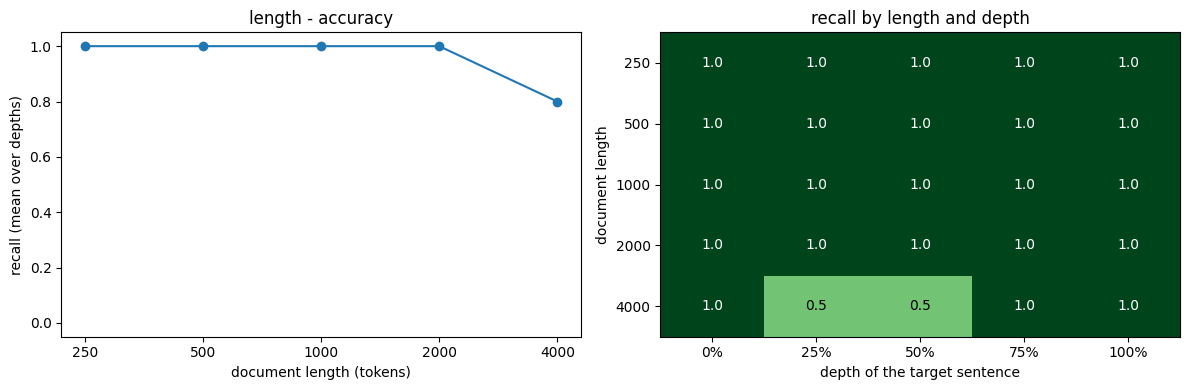

L=  250: 평균 회수율 1.00
L=  500: 평균 회수율 1.00
L=1,000: 평균 회수율 1.00
L=2,000: 평균 회수율 1.00
L=4,000: 평균 회수율 0.80


In [9]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["axes.unicode_minus"] = False

acc = [np.mean([grid[(L, d)] for d in DEPTHS]) for L in LENGTHS]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(LENGTHS, acc, "o-")
ax1.set_xscale("log"); ax1.minorticks_off(); ax1.set_xticks(LENGTHS); ax1.set_xticklabels([str(L) for L in LENGTHS])
ax1.set_ylim(-0.05, 1.05); ax1.set_xlabel("document length (tokens)"); ax1.set_ylabel("recall (mean over depths)")
ax1.set_title("length - accuracy")
M = np.array([[grid[(L, d)] for d in DEPTHS] for L in LENGTHS])
im = ax2.imshow(M, vmin=0, vmax=1, cmap="Greens", aspect="auto")
ax2.set_xticks(range(len(DEPTHS))); ax2.set_xticklabels([f"{d:.0%}" for d in DEPTHS])
ax2.set_yticks(range(len(LENGTHS))); ax2.set_yticklabels([str(L) for L in LENGTHS])
ax2.set_xlabel("depth of the target sentence"); ax2.set_ylabel("document length")
for i in range(len(LENGTHS)):
    for j in range(len(DEPTHS)):
        ax2.text(j, i, f"{M[i, j]:.1f}", ha="center", va="center", color="white" if M[i, j] > 0.6 else "black")
ax2.set_title("recall by length and depth")
plt.tight_layout(); plt.show()
for L, a in zip(LENGTHS, acc):
    print(f"L={L:>5,}: 평균 회수율 {a:.2f}")


if os.environ.get("WEEK07_FIGURE_PATH"):
    fig.savefig(os.environ["WEEK07_FIGURE_PATH"], dpi=140, bbox_inches="tight")

## 3. 같은 모델, 다른 채점 - 답의 첫머리를 빼면

지금까지는 프롬프트 끝에 답의 첫머리("{안내센터} 안내센터의 오늘 임시 출입 번호는")를 미리 적어 두고 6토큰만 생성했다. 이번에는 첫머리를 빼고 `답:`에서 끝낸다. 생성 길이는 8토큰과 24토큰 두 가지로 잰다. 문서와 숨긴 문장, 모델은 그대로다.

결과를 보기 전에 예측해 보자. 모델이 번호를 "아는지"는 바뀌지 않았다. 그런데 회수율도 그대로일까?

In [10]:
L_fmt = 500
print("[답 첫머리 없음, 8토큰 생성]")
g8 = run_grid([L_fmt], answer_prefix=False, max_new_tokens=8, show_miss=False)
print("\n[답 첫머리 없음, 24토큰 생성]")
g24 = run_grid([L_fmt], answer_prefix=False, max_new_tokens=24, show_miss=False)
print("\n깊이 50% 애월의 답 비교")
for prefix, n_new in [(True, 6), (False, 8), (False, 24)]:
    ans, _ = ask(build_prompt(L_fmt, 0.5, "애월", answer_prefix=prefix), n_new)
    print(f"  첫머리 {'있음' if prefix else '없음'}, {n_new:>2}토큰: {ans.strip()!r}")

[답 첫머리 없음, 8토큰 생성]


L=  500 (입력 약 746토큰, 49초) |   0%:0.0   25%:0.0   50%:0.0   75%:0.0  100%:0.0

[답 첫머리 없음, 24토큰 생성]


L=  500 (입력 약 746토큰, 77초) |   0%:1.0   25%:1.0   50%:1.0   75%:1.0  100%:1.0

깊이 50% 애월의 답 비교


  첫머리 있음,  6토큰: '7468이다'


  첫머리 없음,  8토큰: '애월 안내센터의 오늘'


  첫머리 없음, 24토큰: '애월 안내센터의 오늘 임시 출입 번호는 7468이다.'


In [11]:
# 실제 실행 기록 정리. 추가 모델 호출 없이 위에서 얻은 결과만 사용.
from IPython.display import display, Markdown
length_summary = []
for length in LENGTHS:
    records = [r for r in GRID_RECORDS if r["length_budget"] == length and r["answer_prefix"]]
    body_tokens = len(tok(" ".join(haystack(length)), add_special_tokens=False).input_ids)
    row = {"budget": length, "body_tokens": body_tokens,
           "input_min": min(r["input_tokens"] for r in records), "input_max": max(r["input_tokens"] for r in records),
           "hits": sum(r["hit"] for r in records), "trials": len(records),
           "recall": sum(r["hit"] for r in records)/len(records)}
    length_summary.append(row)
lines = ["| 본문 길이 예산 | 실제 본문 토큰 | 전체 입력 토큰 범위 | 회수 성공 | 평균 회수율 |",
         "|---:|---:|---:|---:|---:|"]
for row in length_summary:
    lines.append(f'| {row["budget"]} | {row["body_tokens"]} | {row["input_min"]}-{row["input_max"]} | {row["hits"]}/{row["trials"]} | {row["recall"]:.2f} |')
display(Markdown("\n".join(lines)))
print("답 첫머리 없음 평균 회수율:", {"8토큰": sum(g8.values())/len(g8), "24토큰": sum(g24.values())/len(g24)})
print("원본 2,000토큰 프리필 / 이후 토큰당 디코딩 시간 배율:", prefill_sec[2000]/decode_per_tok)
report = {
    "wiki_oldid": OLDID, "document_sha256": doc_hash, "paragraphs": len(paras), "sentences": len(sents),
    "characters": n_chars, "document_tokens": doc_tokens, "model_revision": MODEL_REVISION,
    "runtime": {"python": sys.version.split()[0], "torch": torch.__version__,
                "transformers": importlib.metadata.version("transformers"), "threads": torch.get_num_threads(), "device": "cpu", "dtype": "float32"},
    "parameters": n_params, "kv_bytes_per_token_bf16": per_token, "weights_bf16": weights,
    "cache_equals_weight_tokens": weights/per_token, "cache32768_weight_ratio": per_token*32768/weights,
    "rope_slow_pairs": sum(t > ML for t in T), "rope_fast_period": T[0], "rope_slow_period": T[-1],
    "prefill_seconds": prefill_sec, "ttft_seconds": ttft, "generate20_seconds": total,
    "decode_seconds_per_token": decode_per_tok, "length_summary": length_summary,
    "grid_records": GRID_RECORDS, "grid_times": GRID_TIMES, "codes": CODES,
    "no_prefix_8_recall": sum(g8.values())/len(g8), "no_prefix_24_recall": sum(g24.values())/len(g24),
}
if os.environ.get("WEEK07_METRICS_PATH"):
    Path(os.environ["WEEK07_METRICS_PATH"]).write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

| 본문 길이 예산 | 실제 본문 토큰 | 전체 입력 토큰 범위 | 회수 성공 | 평균 회수율 |
|---:|---:|---:|---:|---:|
| 250 | 215 | 503-505 | 10/10 | 1.00 |
| 500 | 474 | 762-764 | 10/10 | 1.00 |
| 1000 | 1000 | 1288-1290 | 10/10 | 1.00 |
| 2000 | 1984 | 2272-2274 | 10/10 | 1.00 |
| 4000 | 3969 | 4257-4259 | 8/10 | 0.80 |

답 첫머리 없음 평균 회수율: {'8토큰': 0.0, '24토큰': 1.0}
원본 2,000토큰 프리필 / 이후 토큰당 디코딩 시간 배율: 40.71445055134479


## 4. 확인 질문

1. 1-3에서 KV 캐시가 가중치와 같아지는 길이는 몇 토큰이었나요? 32,768토큰이면 가중치의 몇 배인가요?
2. 1-4에서 최대 위치 안에서 한 바퀴도 못 도는 차원 쌍은 몇 개였나요? 학습 길이를 넘는 위치에서 이 쌍들에 무슨 일이 생기나요?
3. 1-5에서 입력이 2배가 될 때 프리필 시간은 몇 배가 되었나요? 2,000토큰 입력 뒤 디코딩 토큰당 시간은 프리필 시간의 몇 분의 1이었나요? 짧은 답을 받을 때 기다리는 시간의 대부분은 어느 단계인가요?
4. 2에서 길이를 늘렸을 때 회수율은 어떻게 바뀌었나요? 떨어졌다면 어느 깊이에서 먼저 떨어졌나요? 놓친 답은 어떤 번호였나요(다른 안내센터의 번호인가, 없는 번호인가)?
5. 3에서 답의 첫머리를 빼고 8토큰만 생성했을 때 회수율은 얼마였나요? 24토큰에서는요? 모델이 번호를 "알았는지"와 회수율 숫자는 어떤 관계인가요?
6. 이 실험에서 회수율이 1.0이라면 "모델이 문서 전체를 이해했다"고 말할 수 있나요? 이 측정이 말해 주는 것과 말해 주지 않는 것을 한 문장씩 써 보세요.

답은 아래 셀에 글로 적으면 됩니다. 코드가 아니어도 됩니다.

## 실행 결과에 근거한 확인 질문 답

1. **KV 캐시와 가중치의 크기 비교.** bf16 가정의 토큰당 KV 캐시는 114,688바이트(112 KiB), 가중치는 1.1102 GiB. 둘이 같아지는 길이는 10,394.29토큰, 약 10,394토큰. 32,768토큰 캐시는 3.50 GiB로 가중치의 3.153배. 이것은 설정값에서 산출한 메모리 크기이며 실측 peak 메모리가 아님. 실제 실행 dtype은 float32라 같은 KV와 가중치의 바이트 크기는 bf16 가정의 2배이며, 비율은 같음.

2. **느린 RoPE 차원 쌍 24개.** 설정상 최대 위치 32,768 안에서 한 바퀴도 돌지 않는 쌍의 개수. 32,768은 `config.max_position_embeddings` 값이며 실제 사전학습 문맥 길이를 조사해 얻은 값은 아님. 가장 빠른 쌍의 주기는 6.28토큰, 가장 느린 쌍은 약 5,063,256토큰. 학습 때 제한된 각도 범위만 본 느린 쌍은 학습 길이를 넘으면 처음 접하는 각도로 회전하므로 위치 관계의 외삽이 어려워질 수 있음. 위치 보간은 위치를 줄여 기존 각도 범위에 넣고, 기저 확장은 차원 쌍별 회전 속도를 바꾸므로 모든 쌍을 동일 비율로 줄이는 것과 다름. 이 실험은 모델 설정을 읽고 수식을 계산했으며, 확장된 모델을 재학습하거나 최대 길이 밖의 정확도를 검증한 것은 아님.

3. **프리필 시간과 디코딩 시간의 실측 비교.** 입력 2배에 대한 시간 배율은 아래 표와 같음. 한 차례 측정이므로 정확한 계산 복잡도 계수나 다른 장치의 지연을 의미하지 않음.

| 입력 토큰 | 프리필 실측 | 이전 길이 대비 시간 배율 |
|---:|---:|---:|
| 250 | 1.0210초 | - |
| 500 | 2.1322초 | 2.09배 |
| 1,000 | 5.1859초 | 2.43배 |
| 2,000 | 12.4380초 | 2.40배 |
| 4,000 | 34.6015초 | 2.78배 |

   2,000토큰에서 첫 토큰까지 12.2606초, 20토큰 생성까지 18.0650초. 두 시간 차이를 19로 나눈 이후 토큰당 디코딩 추정치는 0.30549초로, 2,000토큰 프리필 시간의 약 1/40.7. 짧은 답에서는 긴 입력을 처음 읽어 캐시를 구성하는 프리필이 큰 대기 비용을 차지함. 각 생성 호출 전체의 차분으로 얻은 근사치이며 개별 토큰마다 타이머를 건 직접 측정값은 아님. 예열은 수행했지만 길이별 반복 측정과 분산 추정은 하지 않음.

4. **길이별·깊이별 정보 회수 결과.** 각 칸은 두 안내센터 질문 중 맞힌 비율, 각 길이 평균은 10회 질문의 평균. 목표 두 개를 여러 배치 위치에서 물은 작은 실험으로, 독립적인 대규모 표본이나 통계적으로 유의한 경향을 뜻하지 않음. 같은 생성 설정에서 길이를 늘린 결과만 비교.

| 본문 길이 예산 | 0% | 25% | 50% | 75% | 100% | 평균 |
|---:|---:|---:|---:|---:|---:|---:|
| 250 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |
| 500 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |
| 1000 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |
| 2000 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |
| 4000 | 1.00 | 0.50 | 0.50 | 1.00 | 1.00 | 0.80 |

길이를 오름차순으로 확인했을 때 첫 실패는 본문 예산 4000토큰, 깊이 25%, 표선 질문. 총 50회 중 2회 실패.

- L=4000, 깊이 25%, 표선: `3471이다` (정답 `9779`; 한림 안내센터의 번호).
- L=4000, 깊이 50%, 표선: `7468이다` (정답 `9779`; 애월 안내센터의 번호).

   목표 깊이는 본문의 문장 인덱스로 삽입한 상대 위치이며 정확한 토큰 비율 위치를 고정한 것은 아님. 길이 예산도 숨긴 10문장과 질문을 제외한 본문용이고, 실제 전체 입력 토큰은 요약 표에 별도로 기록. 정답 판정은 생성문에 정답 4자리 문자열이 들어 있는지의 검사이므로 엄격한 전체 답 일치나 사실성 검사와 구별 필요.

5. **답의 첫머리와 생성 길이에 따른 변화.** 본문 예산 500토큰에서 첫머리를 제공하고 6토큰 생성한 평균 회수율 1.00; 첫머리 없이 8토큰은 0.00, 24토큰은 1.00. 같은 모델·문서·가상 번호라도 답을 시작하는 방식과 허용 출력 길이가 달라지면 번호를 채점 범위 안에서 내놓는지 달라짐. 첫머리 없는 두 조건 사이에서는 생성 길이만 늘린 비교이고, 첫머리 있는 조건과는 프롬프트도 다름. 따라서 짧은 출력의 실패만으로 번호 정보가 내부에 전혀 없다고 단정하거나, 길이를 늘린 성공을 새로 학습한 능력으로 해석할 수 없음.

6. **측정이 말해 주는 것:** 회수율 1.0인 조건에서는 이번 문서·가상 번호·질문과 출력 형식에서 지정 번호 문자열을 모두 생성했음. **측정이 말해 주지 않는 것:** 질문과 숨긴 문장의 표현이 겹치는 두 목표를 설정상 최대 위치 이내에서 시험한 결과로는 문서 전체의 의미 이해, 여러 문서 간 추론, 실제 안내의 사실성 또는 임의 길이·위치에 대한 안정성을 증명할 수 없음.

## 실무 비교: 갱신이 잦은 공공·행정 안내 문서

아래는 대면 비교 항목을 이용한 가정 기반 설계 기록. 제주 행정 안내를 하루 한 번 갱신하고 이용자는 짧은 사실 질문을 한다고 가정. 실제 기관 자료를 수집하거나 RAG 시스템을 실행하지 않았으며, 아래 지연 값은 같은 위키백과의 토큰 길이별 프리필 실험에서 가져온 대리 측정치.

| 기준 | 긴 본문 전체를 입력 | 검색으로 관련 조각을 입력 |
|---|---|---|
| 입력 크기 가정 | 본문 4,000토큰 | 검색 결과 500토큰 |
| 입력 읽기 대리 측정 | 34.6015초 | 2.1322초; 별도 검색/재순위 지연 미측정 |
| bf16 KV 캐시 계산 | 437.50 MiB | 54.69 MiB |
| 문서 갱신 | 최신 본문을 입력마다 반영; 매번 긴 입력을 읽음 | 바뀐 조각의 색인을 갱신해야 최신 검색 가능; 갱신 비용 미측정 |
| 놓칠 수 있는 것 | 긴 입력을 받는 것과 중요한 내용을 이용하는 것은 별개 | 검색에 누락된 정답 조각은 생성 모델이 볼 수 없음 |

갱신이 잦고 질문 범위가 좁다는 이 가정에서는 RAG를 후속 검증 후보로 선택. 입력 읽기와 KV 캐시 감소 가능성이 근거이며, 실제 종단간 속도나 정확도가 좋아졌다는 결론은 아님. [7주차 강의](https://deepnlp-2026.halla.ai/weeks/week-07/)에서 소개한 Lost in the Middle은 중간 위치 정보를 덜 활용할 수 있음을 보여 주므로 전체 문서를 넣었다고 회수 보장을 가정하지 않음. 반대로 이번 문자열 회수 실험의 성공도 그 논문 조건 전체를 재현하거나 반증한 결과가 아님. 실제 선택 전에는 색인 갱신 시간, 검색 재현율, 답의 근거 정확도 및 종단간 지연을 따로 측정해야 함.

## 재현 기록

- 정제 본문: 58문단, 160문장, 10,556자, 7,884토큰. 위키백과 oldid=42464087.
- 정제 문단 SHA256: `63257fcc7658838f8714f4bf09d50e10c91ba62742d7248664b1541c6728f59e`.
- 모델 revision: `da87bfb608c14b7cf20ba1ce41287e8de496c0cd`.
- Python 3.10.0, torch 2.8.0+cpu, transformers 4.57.6, CPU 4 threads, float32. 다운로드·모델 로딩 시간을 프리필 시간에 포함하지 않음.
- 원본을 실행하면서 관측한 결과만 작성. 한 문서, 두 목표 안내센터, 고정된 가상 번호와 탐욕 디코딩 조건에 한정되며 별도 데이터·여러 seed의 재검증은 수행하지 않음.


## 5. 제출

1. 상단 메뉴 **파일 > .ipynb 다운로드** 로 이 노트북을 내려받습니다
2. [저장소](https://github.com/halla-ai/deepnlp-2026)의 `assignments/week-07/<내 학번>/` 에 업로드합니다
3. Pull Request를 엽니다

자세한 방법은 강의 사이트의 **과제 제출** 문서에 있습니다.

---

**막혔나요?** 오류 메시지의 마지막 줄을 먼저 읽어 보세요. 그래도 안 되면 AI Professor 튜터에게 묻고, 그래도 막히면 저장소 Issues에 남기세요.